# 07 - Validation externe sur Br35H

J'évalue le BNN image only et le CNN baseline sur Br35H, un dataset jamais vu à l'entraînement. Je mesure la robustesse OOD, la détection du changement de distribution via l'incertitude, et je valide les Grad-CAM avec les masques de segmentation.

### 1. Imports et seed

In [10]:
import os, json, random, glob
import numpy as np
import torch
import torch.nn as nn
import torchbnn as bnn
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
from scipy.stats import mannwhitneyu
import imagehash

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print(device)

mps


### 2. Chemins et config

In [11]:
BR35H_ROOT = "/Users/teodul/Documents/Memoire/Br35H"
BR35H_YES  = os.path.join(BR35H_ROOT, "yes")
BR35H_NO   = os.path.join(BR35H_ROOT, "no")
ANNOT_PATH = os.path.join(BR35H_ROOT, "Br35H-Mask-RCNN", "annotations_all.json")

EPIC_ROOT  = "/Users/teodul/Documents/Memoire/Brain Tumor MRI clean"
TEST_DIR   = os.path.join(EPIC_ROOT, "Test")

CNN_CKPT   = "runs_cnn_baseline/best_final.pt"
BNN_CKPT   = "runs_bnn_multimodal/ablation_image_only.pt"
SAVE_DIR   = "runs_br35h"
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE    = 224
MC_PASSES   = 50
CLASSES     = ["glioma", "meningioma", "notumor", "pituitary"]
NUM_CLASSES = 4
TUMOR_IDX   = [0, 1, 3]
NOTUMOR_IDX = 2
OOD_T = 8  # seuil plus strict pour garantir un jeu OOD vraiment distinct

### 3. Recharge des modèles

In [12]:
class BNNImageOnly(nn.Module):
    def __init__(self, num_classes=4, prior_mu=0, prior_sigma=0.1):
        super().__init__()
        backbone = models.resnet18(weights="IMAGENET1K_V1")
        backbone.fc = nn.Identity()
        self.cnn = backbone
        for param in self.cnn.parameters():
            param.requires_grad = False
        self.bnn_head = nn.Sequential(
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=512, out_features=256),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=256, out_features=128),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=128, out_features=num_classes),
        )
    def forward(self, img, clinical=None):
        return self.bnn_head(self.cnn(img))


bnn_model = BNNImageOnly().to(device)
ckpt_bnn  = torch.load(BNN_CKPT, map_location=device, weights_only=False)
bnn_model.load_state_dict(ckpt_bnn["model_state"])
print(f"BNN chargé - epoch {ckpt_bnn['epoch']}, AUC={ckpt_bnn['auc']:.3f}")

cnn_baseline = models.resnet18(weights="IMAGENET1K_V1")
cnn_baseline.fc = nn.Sequential(
    nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, NUM_CLASSES)
)
ckpt_cnn = torch.load(CNN_CKPT, map_location=device, weights_only=False)
cnn_baseline.load_state_dict(ckpt_cnn["model_state"])
cnn_baseline = cnn_baseline.to(device)
print(f"CNN chargé - epoch {ckpt_cnn['epoch']}, AUC={ckpt_cnn['auc']:.3f}")

BNN chargé - epoch 15, AUC=0.993
CNN chargé - epoch 8, AUC=0.998


### 4. Transforms et utilitaires

In [13]:
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    return val_tf(img).unsqueeze(0).to(device)

# renvoie mean_probs et std_probs sur les 4 classes
def predict_bnn(img_tensor, clinical=0.5, n_passes=MC_PASSES):
    bnn_model.eval()
    clin_t = torch.tensor([[clinical]], dtype=torch.float32).to(device)
    with torch.no_grad():
        passes = torch.stack([
            torch.softmax(bnn_model(img_tensor, clin_t), dim=1)
            for _ in range(n_passes)
        ])
    return passes.mean(dim=0).cpu().numpy()[0], passes.std(dim=0).cpu().numpy()[0]

# renvoie les probabilites softmax du CNN baseline
def predict_cnn(img_tensor):
    cnn_baseline.eval()
    with torch.no_grad():
        probs = torch.softmax(cnn_baseline(img_tensor), dim=1)
    return probs.cpu().numpy()[0]

# passage 4 classes vers binaire, P(tumeur) = 1 - P(notumor)
def to_binary(prob_4cls):
    return 1.0 - prob_4cls[NOTUMOR_IDX]

### 5. Inférence zero-shot sur Br35H

Le modèle est entraîné sur Mendeley BT-MRI (4 classes) et évalué tel quel sur Br35H (binaire). Une prédiction compte comme tumeur si l'argmax tombe sur gliome, méningiome ou pituitaire.

In [14]:
yes_paths = sorted(glob.glob(os.path.join(BR35H_YES, "*.jpg")) +
                   glob.glob(os.path.join(BR35H_YES, "*.jpeg")) +
                   glob.glob(os.path.join(BR35H_YES, "*.png")))
no_paths  = sorted(glob.glob(os.path.join(BR35H_NO,  "*.jpg")) +
                   glob.glob(os.path.join(BR35H_NO,  "*.jpeg")) +
                   glob.glob(os.path.join(BR35H_NO,  "*.png")))
print(f"Br35H brut : {len(yes_paths)} yes, {len(no_paths)} no")

# ── filtre pHash avant inférence ──────────────────────────────
def phash_int(p):
    return int(str(imagehash.phash(Image.open(p).convert("L"), hash_size=8)), 16)
def bits(arr):
    return np.unpackbits(arr.view(np.uint8).reshape(-1, 8), axis=1)

train_paths = [p for p in glob.glob(os.path.join(EPIC_ROOT, "Train", "**", "*.*"), recursive=True)
               if p.lower().endswith((".jpg", ".jpeg", ".png"))]
print(f"Hachage de {len(train_paths)} images d'entraînement...")
htr = bits(np.array([phash_int(p) for p in train_paths], dtype=np.uint64))

def is_clean_br35h(p, threshold=OOD_T):
    hb = bits(np.array([phash_int(p)], dtype=np.uint64))
    return (htr ^ hb[0]).sum(axis=1).min() > threshold

yes_paths = [p for p in yes_paths if is_clean_br35h(p)]
no_paths  = [p for p in no_paths  if is_clean_br35h(p)]
print(f"Br35H après filtre : {len(yes_paths)} yes, {len(no_paths)} no")
# ─────────────────────────────────────────────────────────────

results_bnn = {"path": [], "label": [], "p_tumor": [], "sigma_max": [], "pred_idx": []}
results_cnn = {"path": [], "label": [], "p_tumor": [], "pred_idx": []}

for label, paths in [(1, yes_paths), (0, no_paths)]:
    for p in paths:
        img_t = load_image(p)
        mean_b, std_b = predict_bnn(img_t)
        results_bnn["path"].append(p)
        results_bnn["label"].append(label)
        results_bnn["p_tumor"].append(to_binary(mean_b))
        results_bnn["sigma_max"].append(std_b.max())
        results_bnn["pred_idx"].append(int(mean_b.argmax()))

        prob_c = predict_cnn(img_t)
        results_cnn["path"].append(p)
        results_cnn["label"].append(label)
        results_cnn["p_tumor"].append(to_binary(prob_c))
        results_cnn["pred_idx"].append(int(prob_c.argmax()))

for d in (results_bnn, results_cnn):
    for k in d:
        d[k] = np.array(d[k]) if k != "path" else d[k]

print(f"✓ Inférence terminée ({len(results_bnn['path'])} images)")

Br35H brut : 1500 yes, 1500 no
Hachage de 4606 images d'entraînement...
Br35H après filtre : 1312 yes, 281 no
✓ Inférence terminée (1593 images)


### 6. Métriques OOD, classification binaire tumeur / pas tumeur

In [15]:
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

def binary_metrics(probs, labels, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        "AUC":   roc_auc_score(labels, probs),
        "BalAcc": balanced_accuracy_score(labels, preds),
        "Acc":   (preds == labels).mean(),
    }

m_bnn = binary_metrics(results_bnn["p_tumor"], results_bnn["label"])
m_cnn = binary_metrics(results_cnn["p_tumor"], results_cnn["label"])

print("Performance OOD (Br35H, binaire tumeur/pas tumeur)")
print(f"  CNN baseline   : AUC={m_cnn['AUC']:.3f}  BalAcc={m_cnn['BalAcc']:.3f}  Acc={m_cnn['Acc']:.3f}")
print(f"  BNN image only : AUC={m_bnn['AUC']:.3f}  BalAcc={m_bnn['BalAcc']:.3f}  Acc={m_bnn['Acc']:.3f}")

Performance OOD (Br35H, binaire tumeur/pas tumeur)
  CNN baseline   : AUC=0.945  BalAcc=0.809  Acc=0.690
  BNN image only : AUC=0.895  BalAcc=0.742  Acc=0.576


### 7. σ BNN, in-distribution (Mendeley BT-MRI) vs OOD (Br35H)

Si l'incertitude est utile, σ doit augmenter sur les données OOD. Je compare les distributions et je teste la différence statistiquement.

σ in-dist  (Mendeley BT-MRI, n=1149) : médiane = 0.0217 ...
σ OOD      (Br35H, n=1593)      : médiane = 0.0570 ...
Mann-Whitney U : stat=603349  p-value=8.89e-53
Ratio σ_OOD / σ_in-dist (médianes) : 2.63


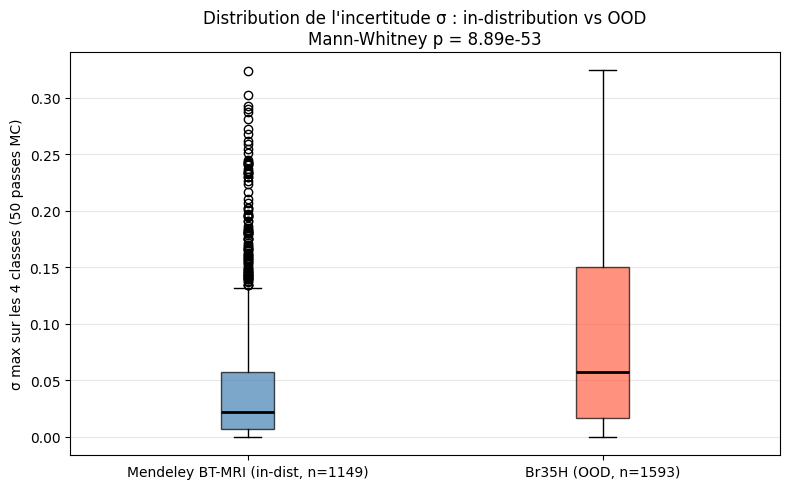

✓ Sauvegardé : ood_metrics.png


In [16]:
sigma_in = []
all_test_paths = []
for cls in CLASSES:
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        all_test_paths.extend(glob.glob(os.path.join(TEST_DIR, cls, ext)))
sample_in = sorted(all_test_paths)

for p in sample_in:
    img_t    = load_image(p)
    _, std_p = predict_bnn(img_t)
    sigma_in.append(std_p.max())
sigma_in = np.array(sigma_in)

sigma_ood = results_bnn["sigma_max"]

# alternative="less" : on teste H1 que sigma in-dist < sigma OOD
stat, pval = mannwhitneyu(sigma_in, sigma_ood, alternative="less")
print(f"σ in-dist  (Mendeley BT-MRI, n={len(sigma_in)}) : médiane = {np.median(sigma_in):.4f} ...")
print(f"σ OOD      (Br35H, n={len(sigma_ood)})      : médiane = {np.median(sigma_ood):.4f} ...")
print(f"Mann-Whitney U : stat={stat:.0f}  p-value={pval:.2e}")
print(f"Ratio σ_OOD / σ_in-dist (médianes) : {np.median(sigma_ood)/np.median(sigma_in):.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([sigma_in, sigma_ood], patch_artist=True,
                medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], ["steelblue", "tomato"]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticks([1, 2])
ax.set_xticklabels([
    f"Mendeley BT-MRI (in-dist, n={len(sigma_in)})",
    f"Br35H (OOD, n={len(sigma_ood)})"
])
ax.set_ylabel("σ max sur les 4 classes (50 passes MC)")
ax.set_title(f"Distribution de l'incertitude σ : in-distribution vs OOD\n"
             f"Mann-Whitney p = {pval:.2e}")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/ood_metrics.png", dpi=150)
plt.show()
print("✓ Sauvegardé : ood_metrics.png")

In [17]:
# Ratio σ incorrect/correct sur Br35H (torchbnn)
correct_bnn = (results_bnn["p_tumor"] >= 0.5).astype(int) == results_bnn["label"]
sigma_ok  = results_bnn["sigma_max"][correct_bnn]
sigma_err = results_bnn["sigma_max"][~correct_bnn]
print(f"torchbnn sur Br35H — {correct_bnn.sum()} corrects / {(~correct_bnn).sum()} erreurs")
print(f"  σ correct   : {sigma_ok.mean():.4f}")
print(f"  σ incorrect : {sigma_err.mean():.4f}")
print(f"  Ratio OOD   : {sigma_err.mean()/sigma_ok.mean():.2f}×")

torchbnn sur Br35H — 917 corrects / 676 erreurs
  σ correct   : 0.0983
  σ incorrect : 0.0712
  Ratio OOD   : 0.72×


### 8. Courbe accuracy vs coverage

Je trie les prédictions par σ croissant et je garde les top X% les plus confiantes. Si σ est utile, l'accuracy doit augmenter quand on filtre les cas incertains.

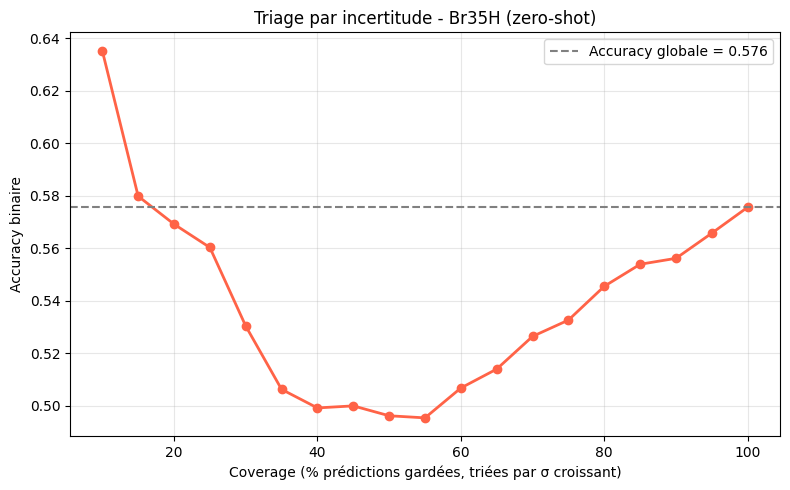

Accuracy top 50% confiantes : 0.496
Accuracy globale            : 0.576

Seuil opérationnel torchbnn :
  Renvoyer les 10% les plus incertains : capture 5.9% des erreurs
  Renvoyer les 20% les plus incertains : capture 14.2% des erreurs
  Renvoyer les 30% les plus incertains : capture 21.7% des erreurs
  Renvoyer les 40% les plus incertains : capture 30.2% des erreurs
  Renvoyer les 50% les plus incertains : capture 40.7% des erreurs


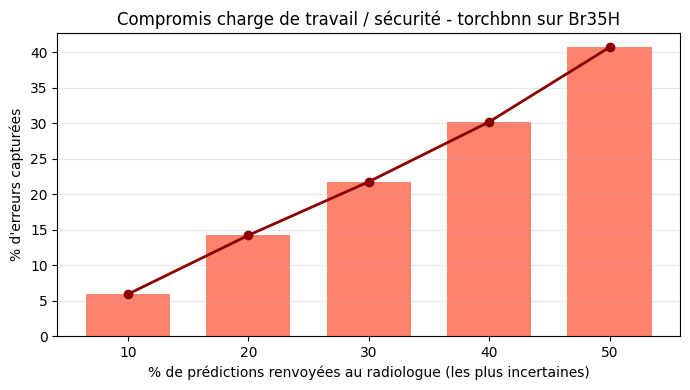

In [18]:
order = np.argsort(results_bnn["sigma_max"])
labels_sorted = results_bnn["label"][order]
probs_sorted  = results_bnn["p_tumor"][order]
preds_sorted  = (probs_sorted >= 0.5).astype(int)
correct_sorted = (preds_sorted == labels_sorted).astype(float)

coverages = np.linspace(0.1, 1.0, 19)
accs = []
for c in coverages:
    k = int(c * len(correct_sorted))
    accs.append(correct_sorted[:k].mean() if k > 0 else np.nan)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(coverages * 100, accs, marker="o", color="tomato", linewidth=2)
ax.axhline(correct_sorted.mean(), color="gray", linestyle="--",
           label=f"Accuracy globale = {correct_sorted.mean():.3f}")
ax.set_xlabel("Coverage (% prédictions gardées, triées par σ croissant)")
ax.set_ylabel("Accuracy binaire")
ax.set_title("Triage par incertitude - Br35H (zero-shot)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/coverage_curve.png", dpi=150)

plt.show()
print(f"Accuracy top 50% confiantes : {correct_sorted[:len(correct_sorted)//2].mean():.3f}")
print(f"Accuracy globale            : {correct_sorted.mean():.3f}")
# Seuil opérationnel : en renvoyant les X% les plus incertains (fin du tableau),
# quelle proportion des erreurs capture-t-on ?
errors_sorted = (correct_sorted == 0).astype(float)
n_errors_total = errors_sorted.sum()
n_tot = len(correct_sorted)

print("\nSeuil opérationnel torchbnn :")
for coverage in [0.1, 0.2, 0.3, 0.4, 0.5]:
    k = int(coverage * n_tot)
    errors_captured = errors_sorted[n_tot-k:].sum()
    pct_errors = errors_captured / n_errors_total * 100
    print(f"  Renvoyer les {int(coverage*100)}% les plus incertains : "
          f"capture {pct_errors:.1f}% des erreurs")
coverages_pct = [10, 20, 30, 40, 50]
errors_captured_pct = []

for coverage in [0.1, 0.2, 0.3, 0.4, 0.5]:
    k = int(coverage * n_tot)
    errors_captured = errors_sorted[n_tot-k:].sum()
    errors_captured_pct.append(errors_captured / n_errors_total * 100)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(coverages_pct, errors_captured_pct, color="tomato", alpha=0.8, width=7)
ax.plot(coverages_pct, errors_captured_pct, marker="o", color="darkred", linewidth=2)
ax.set_xlabel("% de prédictions renvoyées au radiologue (les plus incertaines)")
ax.set_ylabel("% d'erreurs capturées")
ax.set_title("Compromis charge de travail / sécurité - torchbnn sur Br35H")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/triage_threshold.png", dpi=150)
plt.show()

### 9. Validation quantitative des Grad-CAM avec masques

Je reconstruis les masques de segmentation depuis les annotations VIA et je mesure le recouvrement avec les cartes Grad-CAM (IoU, pointing game, energy ratio).

In [19]:
with open(ANNOT_PATH, "r") as f:
    annotations = json.load(f)

if "_via_img_metadata" in annotations:
    annot_dict = annotations["_via_img_metadata"]
else:
    annot_dict = annotations

print(f"Annotations chargées : {len(annot_dict)} entrées")

def build_mask(filename, regions, target_size=IMG_SIZE):
    # cherche l'image dans les sous-dossiers TRAIN, VAL, TEST et yes
    img_path = None
    for root in [os.path.join(BR35H_ROOT, "Br35H-Mask-RCNN", sub)
                 for sub in ("TRAIN", "VAL", "TEST")] + [BR35H_YES]:
        candidate = os.path.join(root, filename)
        if os.path.exists(candidate):
            img_path = candidate
            break
    if img_path is None:
        return None, None

    img = Image.open(img_path).convert("RGB")
    W, H = img.size
    mask = np.zeros((H, W), dtype=np.uint8)

    for region in regions:
        shape = region.get("shape_attributes", region)
        xs = shape.get("all_points_x", [])
        ys = shape.get("all_points_y", [])
        if len(xs) >= 3:
            pts = np.array(list(zip(xs, ys)), dtype=np.int32)
            cv2.fillPoly(mask, [pts], 1)

    mask = cv2.resize(mask, (target_size, target_size), interpolation=cv2.INTER_NEAREST)
    return img_path, mask.astype(np.float32)

n_found, n_missing = 0, 0
for key, entry in annot_dict.items():
    fname = entry.get("filename", key)
    regions = entry.get("regions", [])
    if len(regions) == 0:
        continue
    img_path, _ = build_mask(fname, regions)
    if img_path is None:
        n_missing += 1
    else:
        n_found += 1
print(f"Images annotées trouvables : {n_found}  /  manquantes : {n_missing}")

sample_key = list(annot_dict.keys())[0]
sample = annot_dict[sample_key]
print(f"\nExemple : {sample.get('filename', sample_key)}")
print(f"Régions : {len(sample.get('regions', []))}")

Annotations chargées : 801 entrées
Images annotées trouvables : 801  /  manquantes : 0

Exemple : y0.jpg
Régions : 1


In [20]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def compute(self, img_tensor, clinical_tensor, class_idx):
        self.model.eval()
        img_tensor.requires_grad_(True)
        if clinical_tensor is not None:
            logits = self.model(img_tensor, clinical_tensor)
        else:
            logits = self.model(img_tensor)
        self.model.zero_grad()
        logits[0, class_idx].backward()

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = torch.relu(cam).squeeze().cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

gradcam_bnn = GradCAM(bnn_model, bnn_model.cnn.layer4)
gradcam_cnn = GradCAM(cnn_baseline, cnn_baseline.layer4)

def cam_to_size(cam, size=IMG_SIZE):
    return cv2.resize(cam, (size, size), interpolation=cv2.INTER_LINEAR)

def iou_score(cam, mask, threshold=0.5):
    cam_bin = (cam >= threshold).astype(np.float32)
    inter   = (cam_bin * mask).sum()
    union   = ((cam_bin + mask) > 0).astype(np.float32).sum()
    return inter / (union + 1e-8)

def pointing_game(cam, mask):
    h, w = cam.shape
    idx = cam.argmax()
    y, x = idx // w, idx % w
    return float(mask[y, x] > 0)

def energy_ratio(cam, mask):
    return (cam * mask).sum() / (cam.sum() + 1e-8)

In [21]:
clin_neutral = torch.tensor([[0.5]], dtype=torch.float32).to(device)

scores = {"iou_cnn": [], "iou_bnn": [], "iou_sigma": [],
          "pg_cnn":  [], "pg_bnn":  [], "pg_sigma":  [],
          "er_cnn":  [], "er_bnn":  [], "er_sigma":  []}

n_done = 0
N_MAX  = 200

for key, entry in annot_dict.items():
    fname   = entry.get("filename", key)
    regions = entry.get("regions", [])
    if len(regions) == 0:
        continue

    img_path, mask = build_mask(fname, regions)
    if img_path is None or mask.sum() == 0:
        continue

    img_t = load_image(img_path)

    mean_b, _ = predict_bnn(img_t)
    prob_c    = predict_cnn(img_t)

    pred_b = int(np.array([mean_b[i] for i in TUMOR_IDX]).argmax())
    pred_b = TUMOR_IDX[pred_b]
    pred_c = int(np.array([prob_c[i] for i in TUMOR_IDX]).argmax())
    pred_c = TUMOR_IDX[pred_c]

    cam_c = cam_to_size(gradcam_cnn.compute(img_t.clone(), None, pred_c))

    cams = []
    for _ in range(MC_PASSES):
        cams.append(gradcam_bnn.compute(img_t.clone(), clin_neutral, pred_b))
    cams       = np.stack(cams, axis=0)
    cam_b_mean = cam_to_size(cams.mean(axis=0))
    cam_b_std  = cam_to_size(cams.std(axis=0))
    cam_b_std  = (cam_b_std - cam_b_std.min()) / (cam_b_std.max() - cam_b_std.min() + 1e-8)

    scores["iou_cnn"].append(iou_score(cam_c, mask))
    scores["iou_bnn"].append(iou_score(cam_b_mean, mask))
    scores["iou_sigma"].append(iou_score(cam_b_std, mask))

    scores["pg_cnn"].append(pointing_game(cam_c, mask))
    scores["pg_bnn"].append(pointing_game(cam_b_mean, mask))
    scores["pg_sigma"].append(pointing_game(cam_b_std, mask))

    scores["er_cnn"].append(energy_ratio(cam_c, mask))
    scores["er_bnn"].append(energy_ratio(cam_b_mean, mask))
    scores["er_sigma"].append(energy_ratio(cam_b_std, mask))

    n_done += 1
    if n_done >= N_MAX:
        break

for k in scores:
    scores[k] = np.array(scores[k])

print(f"Évalué sur {n_done} images annotées")
print(f"\n{'Métrique':<20} {'CNN':>10} {'BNN moy':>10} {'BNN σ':>10}")
print("-" * 52)
print(f"{'IoU':<20} {scores['iou_cnn'].mean():>10.3f} {scores['iou_bnn'].mean():>10.3f} {scores['iou_sigma'].mean():>10.3f}")
print(f"{'Pointing game':<20} {scores['pg_cnn'].mean():>10.3f} {scores['pg_bnn'].mean():>10.3f} {scores['pg_sigma'].mean():>10.3f}")
print(f"{'Energy ratio':<20} {scores['er_cnn'].mean():>10.3f} {scores['er_bnn'].mean():>10.3f} {scores['er_sigma'].mean():>10.3f}")

Évalué sur 200 images annotées

Métrique                    CNN    BNN moy      BNN σ
----------------------------------------------------
IoU                       0.228      0.172      0.073
Pointing game             0.760      0.435      0.150
Energy ratio              0.170      0.135      0.078


### 10. Visualisation comparative

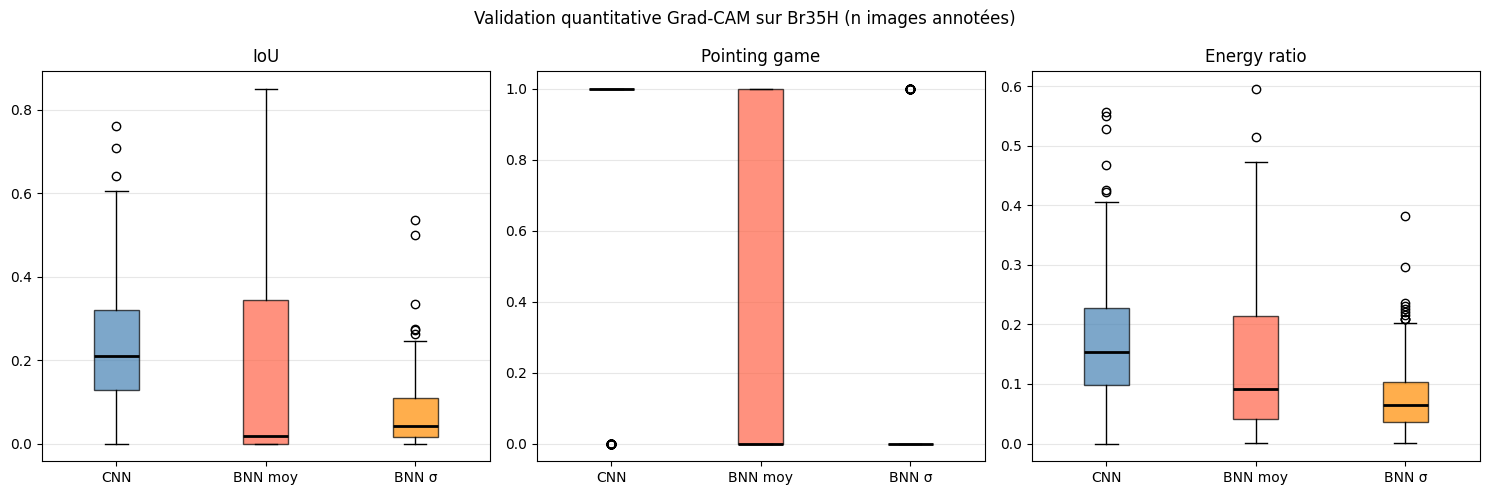

✓ Sauvegardé : gradcam_iou.png


In [22]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
metrics = [("IoU", "iou"), ("Pointing game", "pg"), ("Energy ratio", "er")]
labels  = ["CNN", "BNN moy", "BNN σ"]
colors  = ["steelblue", "tomato", "darkorange"]

for i, (title, key) in enumerate(metrics):
    data = [scores[f"{key}_cnn"], scores[f"{key}_bnn"], scores[f"{key}_sigma"]]
    bp   = ax[i].boxplot(data, patch_artist=True,
                         medianprops=dict(color="black", linewidth=2))
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax[i].set_xticks([1, 2, 3]); ax[i].set_xticklabels(labels)
    ax[i].set_title(title); ax[i].grid(True, alpha=0.3, axis="y")

plt.suptitle("Validation quantitative Grad-CAM sur Br35H (n images annotées)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/gradcam_iou.png", dpi=150)
plt.show()
print("✓ Sauvegardé : gradcam_iou.png")

### 11. Carte σ non normalisée

In [23]:
scores_raw = {"er_sigma_raw": [], "iou_sigma_raw": [], "pg_sigma_raw": []}

n_done2 = 0
for key, entry in annot_dict.items():
    fname   = entry.get("filename", key)
    regions = entry.get("regions", [])
    if len(regions) == 0:
        continue

    img_path, mask = build_mask(fname, regions)
    if img_path is None or mask.sum() == 0:
        continue

    img_t = load_image(img_path)
    mean_b, _ = predict_bnn(img_t)
    pred_b    = TUMOR_IDX[int(np.array([mean_b[i] for i in TUMOR_IDX]).argmax())]

    cams = []
    for _ in range(MC_PASSES):
        cams.append(gradcam_bnn.compute(img_t.clone(), clin_neutral, pred_b))
    cams = np.stack(cams, axis=0)

    cam_std_raw = cam_to_size(cams.std(axis=0))

    threshold = np.median(cam_std_raw)
    cam_bin   = (cam_std_raw >= threshold).astype(np.float32)
    inter     = (cam_bin * mask).sum()
    union     = ((cam_bin + mask) > 0).astype(np.float32).sum()

    scores_raw["iou_sigma_raw"].append(inter / (union + 1e-8))
    scores_raw["er_sigma_raw"].append((cam_std_raw * mask).sum() / (cam_std_raw.sum() + 1e-8))
    scores_raw["pg_sigma_raw"].append(pointing_game(cam_std_raw, mask))

    n_done2 += 1
    if n_done2 >= N_MAX:
        break

for k in scores_raw:
    scores_raw[k] = np.array(scores_raw[k])

print(f"Comparaison normalisation carte σ ({n_done2} images)")
print(f"\n{'Métrique':<25} {'σ normalisée':>15} {'σ brute':>15}")
print("-" * 57)
print(f"{'IoU':<25} {scores['iou_sigma'].mean():>15.3f} {scores_raw['iou_sigma_raw'].mean():>15.3f}")
print(f"{'Pointing game':<25} {scores['pg_sigma'].mean():>15.3f} {scores_raw['pg_sigma_raw'].mean():>15.3f}")
print(f"{'Energy ratio':<25} {scores['er_sigma'].mean():>15.3f} {scores_raw['er_sigma_raw'].mean():>15.3f}")

Comparaison normalisation carte σ (200 images)

Métrique                     σ normalisée         σ brute
---------------------------------------------------------
IoU                                 0.073           0.069
Pointing game                       0.150           0.150
Energy ratio                        0.078           0.079


### 12. Visualisation qualitative

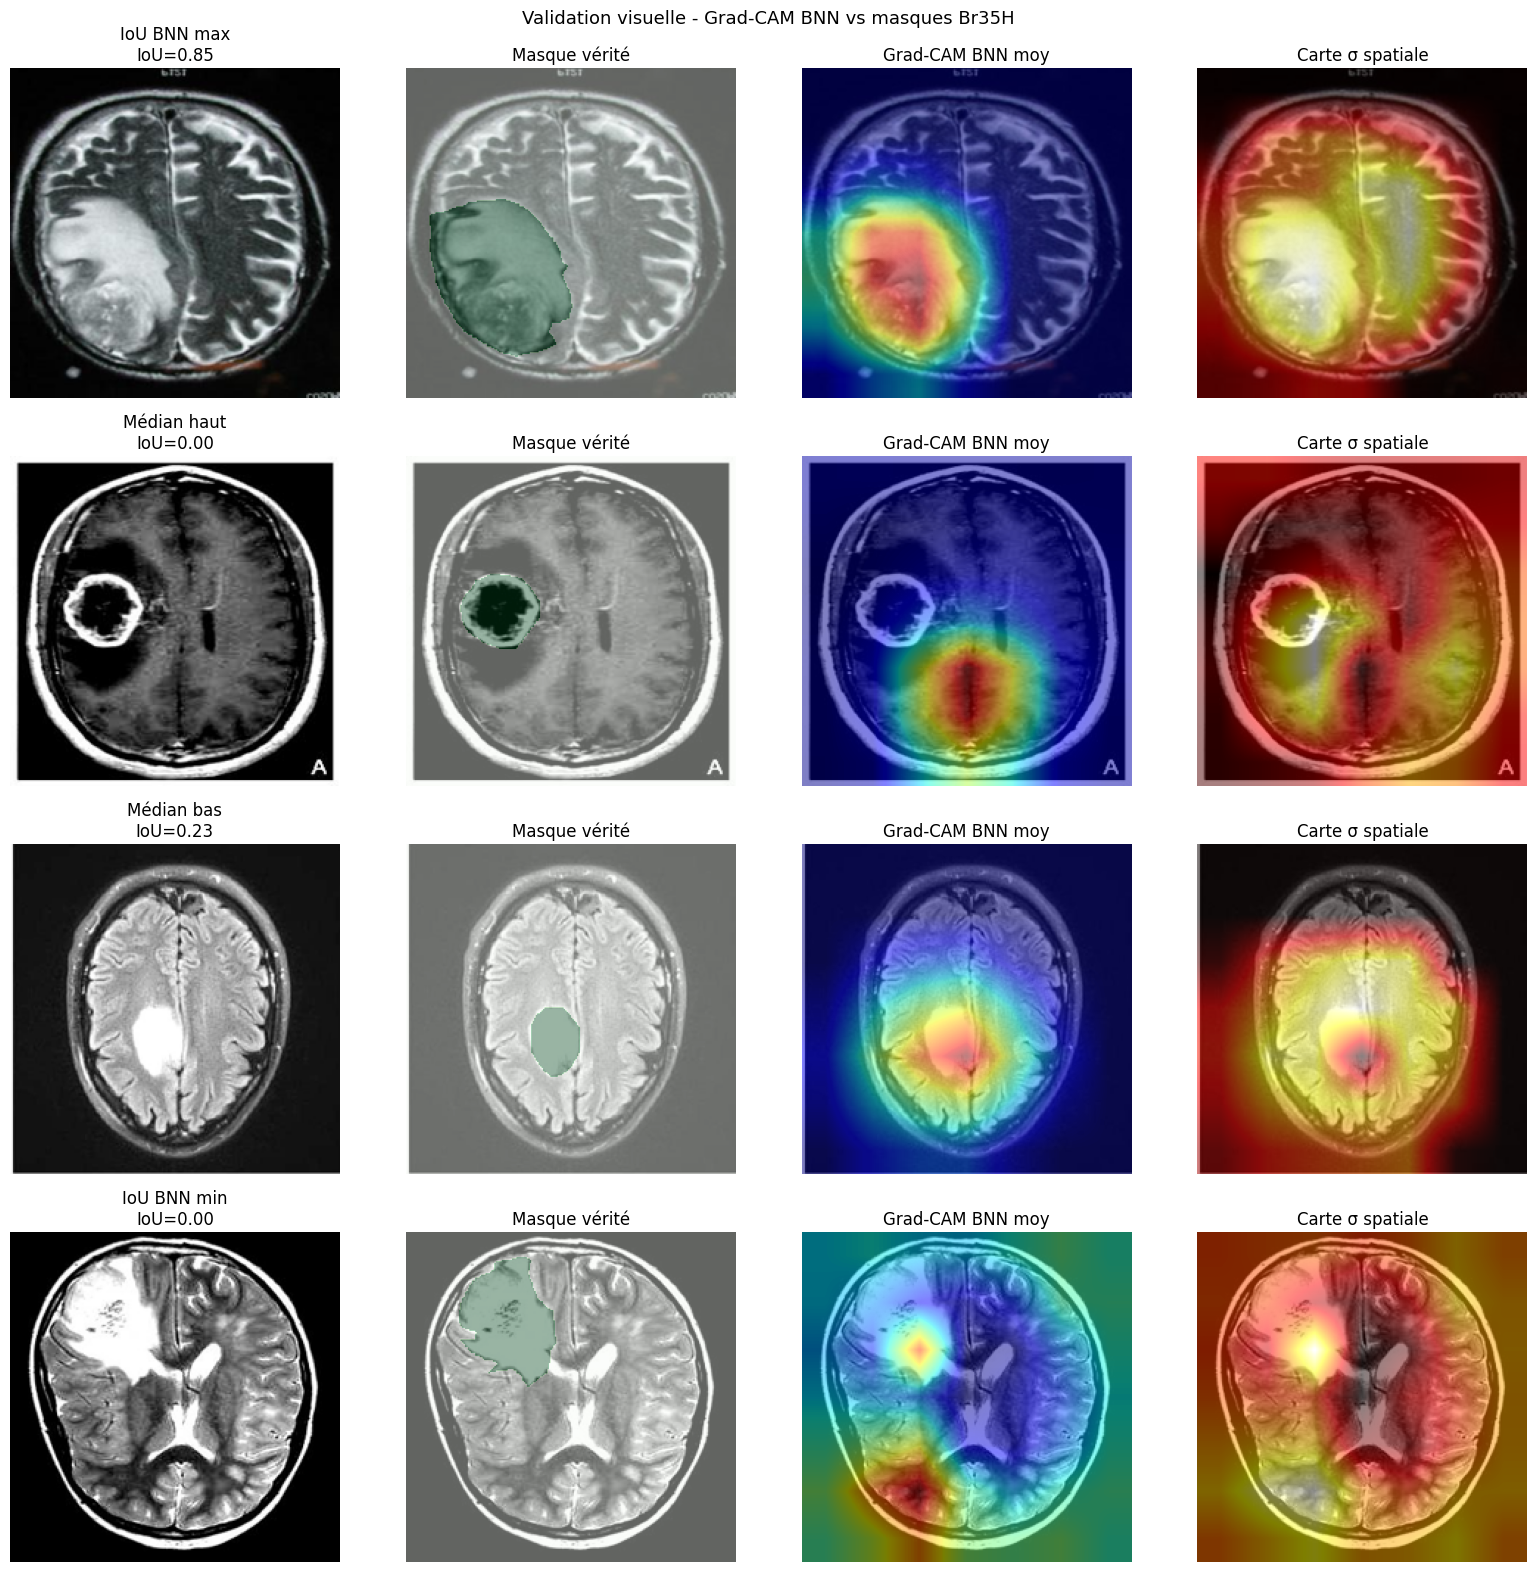

✓ Sauvegardé : sigma_localization.png


In [24]:
order_iou = np.argsort(scores["iou_bnn"])
picks = [order_iou[-1], order_iou[len(order_iou)//3],
         order_iou[2*len(order_iou)//3], order_iou[0]]
titles_pick = ["IoU BNN max", "Médian haut", "Médian bas", "IoU BNN min"]

keys_done = []
for key, entry in annot_dict.items():
    fname   = entry.get("filename", key)
    regions = entry.get("regions", [])
    if len(regions) == 0:
        continue
    img_path, mask = build_mask(fname, regions)
    if img_path is None or mask.sum() == 0:
        continue
    keys_done.append((img_path, mask))
    if len(keys_done) >= n_done:
        break

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for row, (idx, title) in enumerate(zip(picks, titles_pick)):
    img_path, mask = keys_done[idx]
    img_np = np.array(Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE)))
    img_t  = load_image(img_path)

    mean_b, _ = predict_bnn(img_t)
    pred_b    = TUMOR_IDX[int(np.array([mean_b[i] for i in TUMOR_IDX]).argmax())]

    cams = []
    for _ in range(MC_PASSES):
        cams.append(gradcam_bnn.compute(img_t.clone(), clin_neutral, pred_b))
    cams = np.stack(cams, axis=0)
    cam_mean = cam_to_size(cams.mean(axis=0))
    cam_std  = cam_to_size(cams.std(axis=0))
    cam_std  = (cam_std - cam_std.min()) / (cam_std.max() - cam_std.min() + 1e-8)

    axes[row, 0].imshow(img_np);                           axes[row, 0].axis("off")
    axes[row, 0].set_title(f"{title}\nIoU={scores['iou_bnn'][idx]:.2f}")
    axes[row, 1].imshow(img_np); axes[row, 1].imshow(mask, alpha=0.4, cmap="Greens")
    axes[row, 1].axis("off");    axes[row, 1].set_title("Masque vérité")
    axes[row, 2].imshow(img_np); axes[row, 2].imshow(cam_mean, alpha=0.5, cmap="jet")
    axes[row, 2].axis("off");    axes[row, 2].set_title("Grad-CAM BNN moy")
    axes[row, 3].imshow(img_np); axes[row, 3].imshow(cam_std, alpha=0.5, cmap="hot")
    axes[row, 3].axis("off");    axes[row, 3].set_title("Carte σ spatiale")

plt.suptitle("Validation visuelle - Grad-CAM BNN vs masques Br35H", fontsize=13)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/sigma_localization.png", dpi=150)
plt.show()
print("✓ Sauvegardé : sigma_localization.png")

### 13. Comparaison triple, CNN baseline / torchbnn / MC Dropout sur Br35H

J'évalue le modèle MC Dropout du notebook 06 sur Br35H pour le comparer aux deux autres.

In [25]:
MCD_CKPT = "runs_mc_dropout/best.pt"

class MCDropoutImageOnly(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()
        backbone = models.resnet18(weights="IMAGENET1K_V1")
        backbone.fc = nn.Identity()
        self.cnn = backbone
        for name, param in self.cnn.named_parameters():
            if "layer4" in name or "layer3" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, img, clin=None):
        return self.head(self.cnn(img))

    def enable_mc_dropout(self):
        for m in self.modules():
            if isinstance(m, nn.Dropout):
                m.train()


mcd_model = MCDropoutImageOnly().to(device)
ckpt_mcd  = torch.load(MCD_CKPT, map_location=device, weights_only=False)
mcd_model.load_state_dict(ckpt_mcd["model_state"])
print(f"MC Dropout chargé - epoch {ckpt_mcd['epoch']}, AUC={ckpt_mcd['auc']:.3f}")

def predict_mcd(img_tensor, clinical=0.5, n_passes=MC_PASSES):
    mcd_model.eval()
    mcd_model.enable_mc_dropout()
    with torch.no_grad():
        passes = torch.stack([
            torch.softmax(mcd_model(img_tensor), dim=1)
            for _ in range(n_passes)
        ])
    return passes.mean(dim=0).cpu().numpy()[0], passes.std(dim=0).cpu().numpy()[0]

MC Dropout chargé - epoch 5, AUC=0.998


In [26]:
results_mcd = {"path": [], "label": [], "p_tumor": [], "sigma_max": [], "pred_idx": []}

for label, paths in [(1, yes_paths), (0, no_paths)]:
    for p in paths:
        img_t = load_image(p)
        mean_m, std_m = predict_mcd(img_t)
        results_mcd["path"].append(p)
        results_mcd["label"].append(label)
        results_mcd["p_tumor"].append(to_binary(mean_m))
        results_mcd["sigma_max"].append(std_m.max())
        results_mcd["pred_idx"].append(int(mean_m.argmax()))

for k in results_mcd:
    results_mcd[k] = np.array(results_mcd[k]) if k != "path" else results_mcd[k]

m_mcd = binary_metrics(results_mcd["p_tumor"], results_mcd["label"])

print("Performance OOD comparée (Br35H, binaire)")
print(f"\n{'Modèle':<25} {'AUC':>8} {'BalAcc':>8} {'Acc':>8}")
print("-" * 51)
print(f"{'CNN baseline':<25} {m_cnn['AUC']:>8.3f} {m_cnn['BalAcc']:>8.3f} {m_cnn['Acc']:>8.3f}")
print(f"{'BNN torchbnn':<25} {m_bnn['AUC']:>8.3f} {m_bnn['BalAcc']:>8.3f} {m_bnn['Acc']:>8.3f}")
print(f"{'BNN MC Dropout':<25} {m_mcd['AUC']:>8.3f} {m_mcd['BalAcc']:>8.3f} {m_mcd['Acc']:>8.3f}")

Performance OOD comparée (Br35H, binaire)

Modèle                         AUC   BalAcc      Acc
---------------------------------------------------
CNN baseline                 0.945    0.809    0.690
BNN torchbnn                 0.895    0.742    0.576
BNN MC Dropout               0.939    0.796    0.666


In [27]:
sigma_in_mcd = []
for p in sample_in:
    img_t       = load_image(p)
    _, std_p    = predict_mcd(img_t)
    sigma_in_mcd.append(std_p.max())
sigma_in_mcd = np.array(sigma_in_mcd)
sigma_ood_mcd = results_mcd["sigma_max"]

stat_mcd, pval_mcd = mannwhitneyu(sigma_in_mcd, sigma_ood_mcd, alternative="less")
ratio_mcd = np.median(sigma_ood_mcd) / np.median(sigma_in_mcd)

print(f"\n{'Méthode':<20} {'σ in-dist':>12} {'σ OOD':>12} {'Ratio':>8} {'p-value':>12}")
print("-" * 70)
print(f"{'torchbnn':<20} {np.median(sigma_in):>12.4f} {np.median(sigma_ood):>12.4f} "
      f"{np.median(sigma_ood)/np.median(sigma_in):>8.2f} {pval:>12.2e}")
print(f"{'MC Dropout':<20} {np.median(sigma_in_mcd):>12.4f} {np.median(sigma_ood_mcd):>12.4f} "
      f"{ratio_mcd:>8.2f} {pval_mcd:>12.2e}")


Méthode                 σ in-dist        σ OOD    Ratio      p-value
----------------------------------------------------------------------
torchbnn                   0.0217       0.0570     2.63     8.89e-53
MC Dropout                 0.0010       0.0302    29.85    1.33e-143


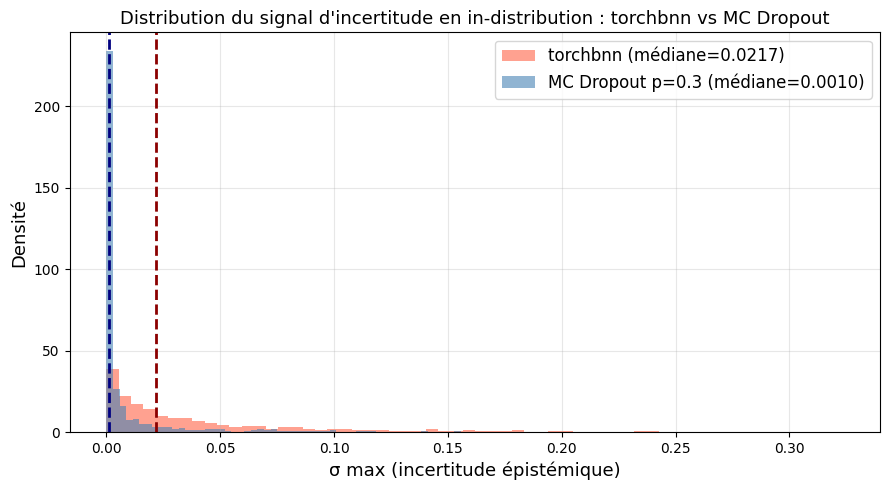

✓ Sauvegardé : sigma_comparison_indist.png


In [28]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(sigma_in, bins=60, alpha=0.6, color="tomato",
        label=f"torchbnn (médiane={np.median(sigma_in):.4f})", density=True)
ax.hist(sigma_in_mcd, bins=60, alpha=0.6, color="steelblue",
        label=f"MC Dropout p=0.3 (médiane={np.median(sigma_in_mcd):.4f})", density=True)
ax.axvline(np.median(sigma_in), color="darkred", linestyle="--", linewidth=2)
ax.axvline(np.median(sigma_in_mcd), color="navy", linestyle="--", linewidth=2)
ax.set_xlabel("σ max (incertitude épistémique)", fontsize=13)
ax.set_ylabel("Densité", fontsize=13)
ax.set_title("Distribution du signal d'incertitude en in-distribution : torchbnn vs MC Dropout", fontsize=13)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/sigma_comparison_indist.png", dpi=150)
plt.show()
print("✓ Sauvegardé : sigma_comparison_indist.png")

In [29]:
# comparaison du sigma absolu en distribution
# le ratio OOD/in-dist favorise MC Dropout car son sigma in-dist est quasi nul
# le sigma absolu en distribution montre la vraie difference
print("Signal d'incertitude en distribution (test propre)")
print(f"  torchbnn   sigma median in-dist : {np.median(sigma_in):.4f}")
print(f"  MC Dropout sigma median in-dist : {np.median(sigma_in_mcd):.4f}")
print()
print("Un sigma in-dist quasi nul pour MC Dropout signifie un modele")
print("quasi deterministe en distribution, sans signal d'incertitude")
print("exploitable pour stratifier le risque par prediction.")

Signal d'incertitude en distribution (test propre)
  torchbnn   sigma median in-dist : 0.0217
  MC Dropout sigma median in-dist : 0.0010

Un sigma in-dist quasi nul pour MC Dropout signifie un modele
quasi deterministe en distribution, sans signal d'incertitude
exploitable pour stratifier le risque par prediction.


In [30]:
# Ratio σ incorrect/correct sur Br35H (MC Dropout)
correct_mcd = (results_mcd["p_tumor"] >= 0.5).astype(int) == results_mcd["label"]
sigma_ok_m  = results_mcd["sigma_max"][correct_mcd]
sigma_err_m = results_mcd["sigma_max"][~correct_mcd]
print(f"MC Dropout sur Br35H — {correct_mcd.sum()} corrects / {(~correct_mcd).sum()} erreurs")
print(f"  σ correct   : {sigma_ok_m.mean():.4f}")
print(f"  σ incorrect : {sigma_err_m.mean():.4f}")
if len(sigma_ok_m) > 0 and sigma_ok_m.mean() > 0:
    print(f"  Ratio OOD   : {sigma_err_m.mean()/sigma_ok_m.mean():.2f}×")
else:
    print("  Ratio OOD   : incalculable (0 corrects)")

MC Dropout sur Br35H — 1061 corrects / 532 erreurs
  σ correct   : 0.0513
  σ incorrect : 0.0468
  Ratio OOD   : 0.91×



Gain en accuracy par triage (top 50% les plus confiantes) :
  torchbnn   : 0.576 -> 0.496  (+-7.9 pts)
  MC Dropout : 0.666 -> 0.646  (+-2.0 pts)


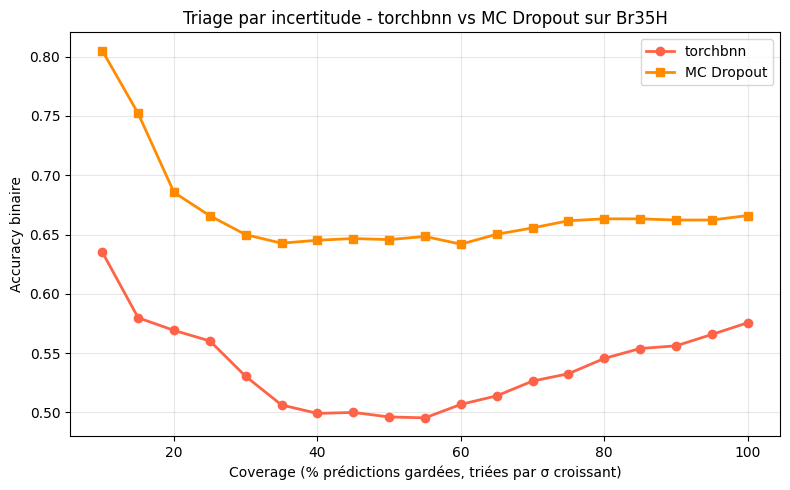

In [31]:
order_mcd = np.argsort(results_mcd["sigma_max"])
labels_sorted_mcd = results_mcd["label"][order_mcd]
probs_sorted_mcd  = results_mcd["p_tumor"][order_mcd]
correct_mcd_sorted = ((probs_sorted_mcd >= 0.5).astype(int) == labels_sorted_mcd).astype(float)

accs_mcd = []
for c in coverages:
    k = int(c * len(correct_mcd_sorted))
    accs_mcd.append(correct_mcd_sorted[:k].mean() if k > 0 else np.nan)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(coverages * 100, accs,     marker="o", color="tomato",    linewidth=2, label="torchbnn")
ax.plot(coverages * 100, accs_mcd, marker="s", color="darkorange", linewidth=2, label="MC Dropout")
ax.set_xlabel("Coverage (% prédictions gardées, triées par σ croissant)")
ax.set_ylabel("Accuracy binaire")
ax.set_title("Triage par incertitude - torchbnn vs MC Dropout sur Br35H")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/coverage_comparison.png", dpi=150)

n_tot = len(correct_sorted)
acc_global_torchbnn  = correct_sorted.mean()
acc_top50_torchbnn   = correct_sorted[:n_tot//2].mean()
acc_global_mcd       = correct_mcd_sorted.mean()
acc_top50_mcd        = correct_mcd_sorted[:n_tot//2].mean()

print(f"\nGain en accuracy par triage (top 50% les plus confiantes) :")
print(f"  torchbnn   : {acc_global_torchbnn:.3f} -> {acc_top50_torchbnn:.3f}  "
      f"(+{(acc_top50_torchbnn-acc_global_torchbnn)*100:.1f} pts)")
print(f"  MC Dropout : {acc_global_mcd:.3f} -> {acc_top50_mcd:.3f}  "
      f"(+{(acc_top50_mcd-acc_global_mcd)*100:.1f} pts)")

plt.show()

### 14. Ablation, sensibilité au taux de dropout

MC Dropout introduit un hyperparamètre arbitraire que torchbnn n'a pas. Je vérifie si le comportement OOD dépend du taux choisi.

In [32]:
class MCDropoutImageOnly(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()
        backbone = models.resnet18(weights="IMAGENET1K_V1")
        backbone.fc = nn.Identity()
        self.cnn = backbone
        for name, param in self.cnn.named_parameters():
            if "layer4" in name or "layer3" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, img, clin=None):
        return self.head(self.cnn(img))

    def enable_mc_dropout(self):
        for m in self.modules():
            if isinstance(m, nn.Dropout):
                m.train()


def predict_with_model(model_obj, img_tensor, clinical=0.5, n_passes=MC_PASSES):
    model_obj.eval()
    model_obj.enable_mc_dropout()
    with torch.no_grad():
        passes = torch.stack([
            torch.softmax(model_obj(img_tensor), dim=1)
            for _ in range(n_passes)
        ])
    return passes.mean(dim=0).cpu().numpy()[0], passes.std(dim=0).cpu().numpy()[0]


def evaluate_mcd_full(model_obj, n_passes=MC_PASSES):
    sigma_in_ref = []
    for p in sample_in:
        img_t = load_image(p)
        _, std_p = predict_with_model(model_obj, img_t, n_passes=n_passes)
        sigma_in_ref.append(std_p.max())
    sigma_in_ref = np.array(sigma_in_ref)

    sigma_ood_full, p_tumor_ood, label_ood = [], [], []
    for label, paths in [(1, yes_paths), (0, no_paths)]:
        for p in paths:
            img_t = load_image(p)
            mean_p, std_p = predict_with_model(model_obj, img_t, n_passes=n_passes)
            sigma_ood_full.append(std_p.max())
            p_tumor_ood.append(1.0 - mean_p[NOTUMOR_IDX])
            label_ood.append(label)
    sigma_ood_full = np.array(sigma_ood_full)
    p_tumor_ood    = np.array(p_tumor_ood)
    label_ood      = np.array(label_ood)
    preds_ood      = (p_tumor_ood >= 0.5).astype(int)

    auc_ood    = roc_auc_score(label_ood, p_tumor_ood)
    balacc_ood = balanced_accuracy_score(label_ood, preds_ood)

    sigma_ood_subsample = sigma_ood_full
    stat, pval = mannwhitneyu(sigma_in_ref, sigma_ood_subsample, alternative="less")
    ratio_ood  = np.median(sigma_ood_subsample) / np.median(sigma_in_ref)

    return {
        "AUC_ood":    auc_ood,
        "BalAcc_ood": balacc_ood,
        "sigma_in":   np.median(sigma_in_ref),
        "sigma_ood":  np.median(sigma_ood_subsample),
        "ratio_ood":  ratio_ood,
        "pval_ood":   pval,
    }


ABLATION_DIR = "runs_mc_dropout_ablation"
checkpoints  = {
    0.2: f"{ABLATION_DIR}/mcd_dropout_0.2.pt",
    0.3: "runs_mc_dropout/best.pt",
    0.5: f"{ABLATION_DIR}/mcd_dropout_0.5.pt",
}

results_ablation = {}
for rate, ckpt_path in checkpoints.items():
    print(f"\n=== Évaluation dropout={rate} ===")
    m = MCDropoutImageOnly(dropout=rate).to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    m.load_state_dict(ckpt["model_state"])
    auc_id_saved = ckpt.get("auc", float("nan"))
    results_ablation[rate] = evaluate_mcd_full(m)
    results_ablation[rate]["AUC_id_val"] = auc_id_saved
    r = results_ablation[rate]
    print(f"  AUC val  in-dist  = {auc_id_saved:.4f}")
    print(f"  AUC OOD           = {r['AUC_ood']:.4f}  BalAcc = {r['BalAcc_ood']:.4f}")
    print(f"  Ratio σ OOD       = {r['ratio_ood']:.2f}  (p = {r['pval_ood']:.2e})")


=== Évaluation dropout=0.2 ===
  AUC val  in-dist  = 0.9981
  AUC OOD           = 0.9046  BalAcc = 0.8084
  Ratio σ OOD       = 27.27  (p = 5.60e-148)

=== Évaluation dropout=0.3 ===
  AUC val  in-dist  = 0.9981
  AUC OOD           = 0.9389  BalAcc = 0.7929
  Ratio σ OOD       = 29.90  (p = 1.37e-141)

=== Évaluation dropout=0.5 ===
  AUC val  in-dist  = 0.9984
  AUC OOD           = 0.9461  BalAcc = 0.8244
  Ratio σ OOD       = 18.90  (p = 1.40e-124)



Méthode                  AUC val   AUC OOD   BalAcc OOD   Ratio σ    p-value
---------------------------------------------------------------------------
torchbnn                  0.9951     0.895        0.742      2.63   8.89e-53
MC Dropout p=0.2          0.9981     0.905        0.808     27.27  5.60e-148
MC Dropout p=0.3          0.9981     0.939        0.793     29.90  1.37e-141
MC Dropout p=0.5          0.9984     0.946        0.824     18.90  1.40e-124


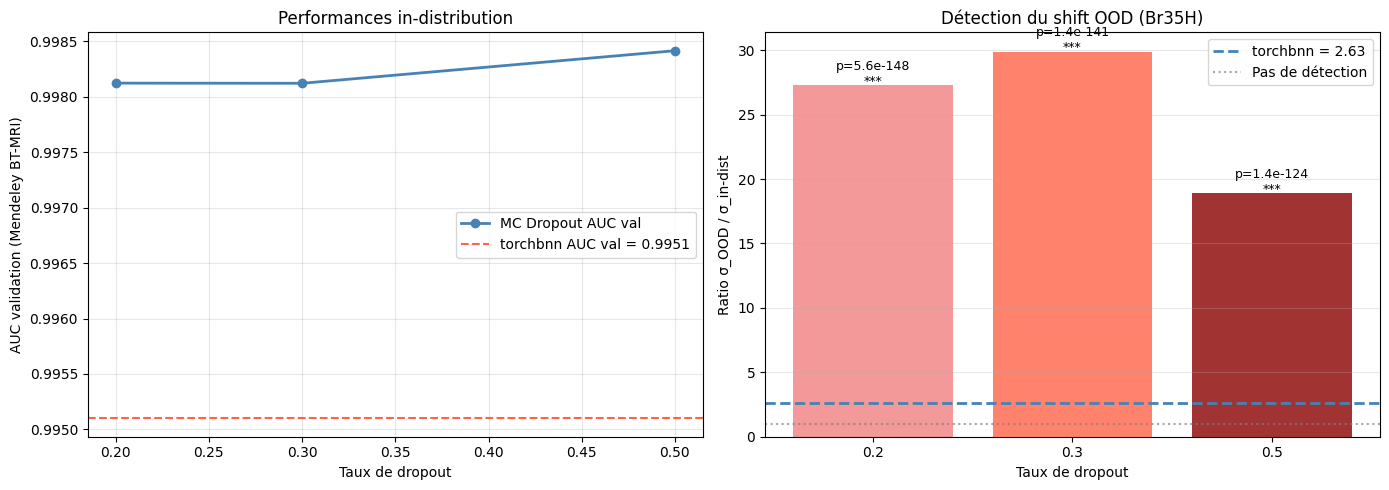

✓ Sauvegardé : dropout_sensitivity.png


In [33]:
print(f"\n{'Méthode':<22} {'AUC val':>9} {'AUC OOD':>9} {'BalAcc OOD':>12} {'Ratio σ':>9} {'p-value':>10}")
print("-" * 75)

torchbnn_row = {
    "AUC_val":    0.9951,
    "AUC_ood":    m_bnn["AUC"],
    "BalAcc_ood": m_bnn["BalAcc"],
    "ratio_ood":  np.median(sigma_ood) / np.median(sigma_in),
    "pval_ood":   pval,
}
r = torchbnn_row
print(f"{'torchbnn':<22} {r['AUC_val']:>9.4f} {r['AUC_ood']:>9.3f} {r['BalAcc_ood']:>12.3f} "
      f"{r['ratio_ood']:>9.2f} {r['pval_ood']:>10.2e}")

for rate in [0.2, 0.3, 0.5]:
    r = results_ablation[rate]
    print(f"{'MC Dropout p='+str(rate):<22} {r['AUC_id_val']:>9.4f} {r['AUC_ood']:>9.3f} "
          f"{r['BalAcc_ood']:>12.3f} {r['ratio_ood']:>9.2f} {r['pval_ood']:>10.2e}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rates  = [0.2, 0.3, 0.5]
ratios = [results_ablation[r]["ratio_ood"] for r in rates]
pvals  = [results_ablation[r]["pval_ood"]  for r in rates]
auc_ids_val = [results_ablation[r]["AUC_id_val"] for r in rates]

axes[0].plot(rates, auc_ids_val, marker="o", color="steelblue", linewidth=2,
             label="MC Dropout AUC val")
axes[0].axhline(torchbnn_row["AUC_val"], color="tomato", linestyle="--",
                label=f"torchbnn AUC val = {torchbnn_row['AUC_val']:.4f}")
axes[0].set_xlabel("Taux de dropout")
axes[0].set_ylabel("AUC validation (Mendeley BT-MRI)")
axes[0].set_title("Performances in-distribution")
axes[0].grid(True, alpha=0.3); axes[0].legend()

bars = axes[1].bar([str(r) for r in rates], ratios,
                   color=["lightcoral", "tomato", "darkred"], alpha=0.8)
axes[1].axhline(torchbnn_row["ratio_ood"], color="steelblue", linestyle="--",
                linewidth=2, label=f"torchbnn = {torchbnn_row['ratio_ood']:.2f}")
axes[1].axhline(1.0, color="gray", linestyle=":", alpha=0.7, label="Pas de détection")
for bar, p in zip(bars, pvals):
    sig = "ns" if p > 0.05 else ("*" if p > 0.01 else ("**" if p > 0.001 else "***"))
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f"p={p:.1e}\n{sig}", ha="center", fontsize=9)
axes[1].set_xlabel("Taux de dropout")
axes[1].set_ylabel("Ratio σ_OOD / σ_in-dist")
axes[1].set_title("Détection du shift OOD (Br35H)")
axes[1].grid(True, alpha=0.3, axis="y"); axes[1].legend()

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/dropout_sensitivity.png", dpi=150)
plt.show()
print("✓ Sauvegardé : dropout_sensitivity.png")

In [34]:
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

def compute_mcd_indist_metrics(dropout_rate, ckpt_path, n_passes=MC_PASSES):
    m = MCDropoutImageOnly(dropout=dropout_rate).to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    m.load_state_dict(ckpt["model_state"])
    m.eval()

    all_probs, all_labels, all_sigmas = [], [], []
    for p in sample_in:
        cls_name = os.path.basename(os.path.dirname(p))
        label = CLASSES.index(cls_name)
        img_t = load_image(p)
        m.enable_mc_dropout()
        with torch.no_grad():
            passes = torch.stack([
                torch.softmax(m(img_t), dim=1)
                for _ in range(n_passes)
            ])
        mean_p = passes.mean(dim=0).cpu().numpy()[0]
        std_p  = passes.std(dim=0).cpu().numpy()[0]
        all_probs.append(mean_p)
        all_labels.append(label)
        pred_class = mean_p.argmax()
        all_sigmas.append(std_p[pred_class])

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_sigmas = np.array(all_sigmas)
    all_preds  = all_probs.argmax(axis=1)

    auc    = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
    balacc = balanced_accuracy_score(all_labels, all_preds)

    confidences = all_probs.max(axis=1)
    correct = (all_preds == all_labels).astype(float)
    ece = 0.0
    for i in range(10):
        lo, hi = i / 10, (i + 1) / 10
        mask = (confidences >= lo) & (confidences < hi)
        if mask.sum() > 0:
            ece += mask.sum() / len(confidences) * abs(correct[mask].mean() - confidences[mask].mean())

    sigma_median = np.median(all_sigmas)
    correct_mask = all_preds == all_labels
    sigma_ok  = all_sigmas[correct_mask]
    sigma_err = all_sigmas[~correct_mask]
    ratio = sigma_err.mean() / sigma_ok.mean() if len(sigma_ok) > 0 and sigma_ok.mean() > 0 else np.nan

    return {"auc": auc, "balacc": balacc, "ece": ece,
            "sigma_median": sigma_median, "ratio": ratio, "sigmas": all_sigmas}

print("Calcul des métriques in-distribution pour MC Dropout p=0.2 ...")
metrics_02 = compute_mcd_indist_metrics(0.2, f"{ABLATION_DIR}/mcd_dropout_0.2.pt")
print("Calcul des métriques in-distribution pour MC Dropout p=0.5 ...")
metrics_05 = compute_mcd_indist_metrics(0.5, f"{ABLATION_DIR}/mcd_dropout_0.5.pt")

rows = [
    ("torchbnn",         0.9951, 0.9670, 0.0085, 0.0218, 4.83),
    ("MC Dropout p=0.2", metrics_02["auc"], metrics_02["balacc"], metrics_02["ece"],
                         metrics_02["sigma_median"], metrics_02["ratio"]),
    ("MC Dropout p=0.3", 0.9978, 0.9685, 0.0104, 0.0010, 8.37),
    ("MC Dropout p=0.5", metrics_05["auc"], metrics_05["balacc"], metrics_05["ece"],
                         metrics_05["sigma_median"], metrics_05["ratio"]),
]

print(f"\n{'Méthode':<22} {'AUC val':>9} {'BalAcc':>9} {'ECE':>8} {'σ méd. in-dist':>16} {'Ratio σ err/ok':>15}")
print("-" * 83)
for name, auc, bal, ece, sig, rat in rows:
    print(f"{name:<22} {auc:>9.4f} {bal:>9.4f} {ece:>8.4f} {sig:>16.4f} {rat:>15.2f}")

Calcul des métriques in-distribution pour MC Dropout p=0.2 ...
Calcul des métriques in-distribution pour MC Dropout p=0.5 ...

Méthode                  AUC val    BalAcc      ECE   σ méd. in-dist  Ratio σ err/ok
-----------------------------------------------------------------------------------
torchbnn                  0.9951    0.9670   0.0085           0.0218            4.83
MC Dropout p=0.2          0.9976    0.9744   0.0162           0.0007            8.32
MC Dropout p=0.3          0.9978    0.9685   0.0104           0.0010            8.37
MC Dropout p=0.5          0.9987    0.9667   0.0105           0.0020            9.45


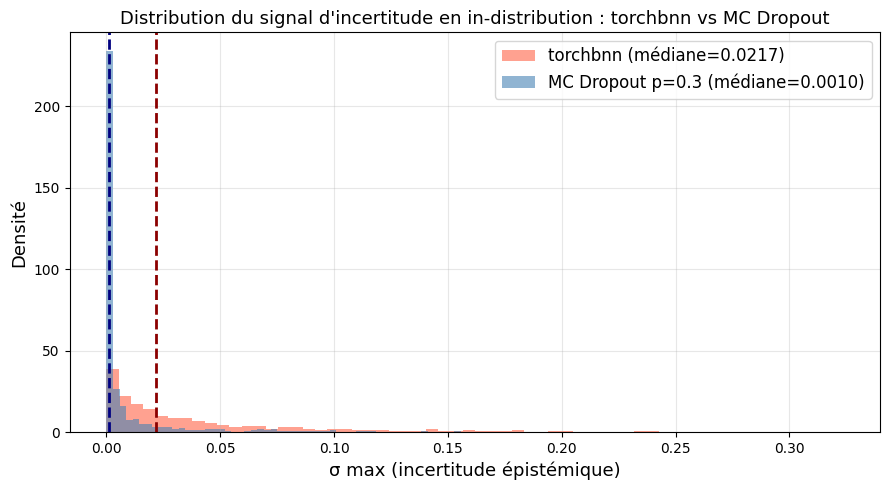

✓ Sauvegardé : sigma_comparison_indist.png


In [35]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(sigma_in, bins=60, alpha=0.6, color="tomato",
        label=f"torchbnn (médiane={np.median(sigma_in):.4f})", density=True)
ax.hist(sigma_in_mcd, bins=60, alpha=0.6, color="steelblue",
        label=f"MC Dropout p=0.3 (médiane={np.median(sigma_in_mcd):.4f})", density=True)
ax.axvline(np.median(sigma_in),     color="darkred", linestyle="--", linewidth=2)
ax.axvline(np.median(sigma_in_mcd), color="navy",    linestyle="--", linewidth=2)
ax.set_xlabel("σ max (incertitude épistémique)", fontsize=13)
ax.set_ylabel("Densité", fontsize=13)
ax.set_title("Distribution du signal d'incertitude en in-distribution : torchbnn vs MC Dropout", fontsize=13)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/sigma_comparison_indist.png", dpi=150)
plt.show()
print("✓ Sauvegardé : sigma_comparison_indist.png")

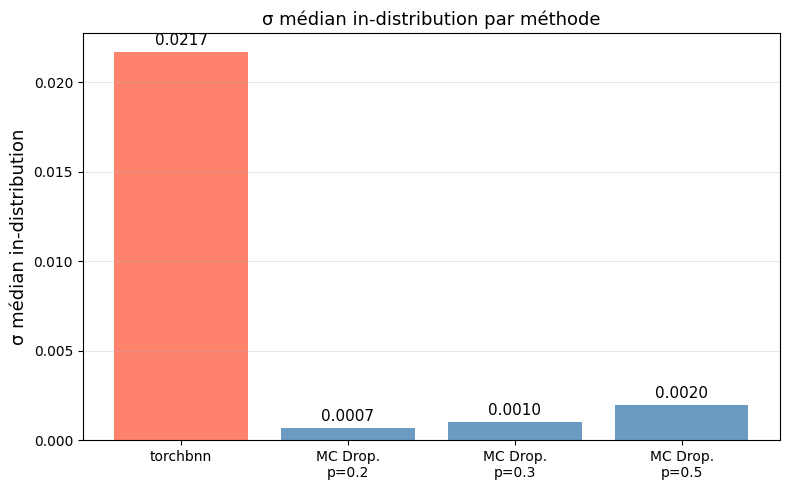

✓ Sauvegardé : sigma_median_comparison.png


In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
method_labels = ["torchbnn", "MC Drop.\np=0.2", "MC Drop.\np=0.3", "MC Drop.\np=0.5"]
sigma_medians = [
    np.median(sigma_in),
    metrics_02["sigma_median"],
    np.median(sigma_in_mcd),
    metrics_05["sigma_median"],
]
bar_colors = ["tomato", "steelblue", "steelblue", "steelblue"]
bars = ax.bar(method_labels, sigma_medians, color=bar_colors, alpha=0.8)
for bar, val in zip(bars, sigma_medians):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(sigma_medians) * 0.01,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11)
ax.set_ylabel("σ médian in-distribution", fontsize=13)
ax.set_title("σ médian in-distribution par méthode", fontsize=13)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/sigma_median_comparison.png", dpi=150)
plt.show()
print("✓ Sauvegardé : sigma_median_comparison.png")